In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt


from count_FM_function_v3 import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device("cpu")
print("device:", device)

device: cuda


# 1. read data

In [2]:
save_path = "pcx_141208-2_bank2_XC_bin001.npz"

# load
d = np.load(save_path, allow_pickle=True)
X_list = list(d["X_list"])
C_list = list(d["C_list"])
meta_list = list(d["meta_list"])
C_columns = list(d["C_columns"])

print("loaded:", len(X_list), len(C_list))
print("X[0].shape:", X_list[0].shape, "C[0].shape:", C_list[0].shape)
print("C_columns:", C_columns)

loaded: 480 480
X[0].shape: (200, 84) C[0].shape: (200, 4)
C_columns: ['t', 'rrr_mean', 'odor_present', 'odor_id']


In [3]:
X_list[0][0:10,0:10]

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=object)

In [4]:
C_list[0][0:10,:]

array([[-0.495, 3.7955090488105383, 0.0, 0.0],
       [-0.485, 1.8248321119158049, 0.0, 0.0],
       [-0.475, -0.6450817834213126, 0.0, 0.0],
       [-0.46499999999999997, -3.392807093287627, 0.0, 0.0],
       [-0.45499999999999996, -7.097285627171937, 0.0, 0.0],
       [-0.44499999999999995, -11.722603653287091, 0.0, 0.0],
       [-0.43499999999999994, -16.489627641599146, 0.0, 0.0],
       [-0.42499999999999993, -21.83216353535149, 0.0, 0.0],
       [-0.4149999999999999, -27.773576648447715, 0.0, 0.0],
       [-0.4049999999999999, -33.926428590310294, 0.0, 0.0]], dtype=object)

In [5]:
C_list[-1][0:10]

array([[-0.495, 6.162707167307508, 0.0, 15.0],
       [-0.485, 4.959961801523377, 0.0, 15.0],
       [-0.475, 4.305044877913588, 0.0, 15.0],
       [-0.46499999999999997, 3.134677594480672, 0.0, 15.0],
       [-0.45499999999999996, 2.4009101141535667, 0.0, 15.0],
       [-0.44499999999999995, 1.7237897596901348, 0.0, 15.0],
       [-0.43499999999999994, 1.2068998268092854, 0.0, 15.0],
       [-0.42499999999999993, 1.0654843594061731, 0.0, 15.0],
       [-0.4149999999999999, 1.2095321381809299, 0.0, 15.0],
       [-0.4049999999999999, 1.6325776279678395, 0.0, 15.0]], dtype=object)

# 2. flatten data, split and loading

In [6]:
def _force_numeric(arr, dtype):
    a = np.asarray(arr)
    if a.dtype == object:
        return np.array(a, dtype=dtype)
    return a.astype(dtype, copy=False)

X_list = [_force_numeric(x, np.int64) for x in X_list]
C_list = [_force_numeric(c, np.float32) for c in C_list]

print("X_list[0].dtype:", X_list[0].dtype, "shape:", X_list[0].shape)
print("C_list[0].dtype:", C_list[0].dtype, "shape:", C_list[0].shape)

X_list[0].dtype: int64 shape: (200, 84)
C_list[0].dtype: float32 shape: (200, 4)


## 2.1 flatten

In [7]:
X = np.concatenate([x for x in X_list], axis=0)  # (480*200, 84)
C = np.concatenate([c for c in C_list], axis=0)  # (480*200, 4)

mask = np.isfinite(X).all(axis=1) & np.isfinite(C).all(axis=1)
X = X[mask]
C = C[mask]

X = np.clip(X, 0, None).astype(np.int64)

In [8]:
C_cont = C[:, :2].astype(np.float32)
C_bin  = np.rint(C[:, 2]).astype(np.int64)
C_cat  = np.rint(C[:, 3]).astype(np.int64)

In [9]:
print("X shape:", X.shape, "C shape:", C.shape)
print("C_bin unique:", np.unique(C_bin))
print("C_cat min/max:", C_cat.min(), C_cat.max())

X shape: (96000, 84) C shape: (96000, 4)
C_bin unique: [0 1]
C_cat min/max: 0 15


## 2.2 train-test split

In [10]:
N = X.shape[0]
perm = np.random.permutation(N)
n_tr = int(0.9 * N)
tr_idx, va_idx = perm[:n_tr], perm[n_tr:]

In [11]:
Xtr, Xva = X[tr_idx], X[va_idx]
Ctr_cont, Cva_cont = C_cont[tr_idx], C_cont[va_idx]
Ctr_bin,  Cva_bin  = C_bin[tr_idx],  C_bin[va_idx]
Ctr_cat,  Cva_cat  = C_cat[tr_idx],  C_cat[va_idx]

In [12]:
Xtr_t = torch.from_numpy(Xtr).float()
Xva_t = torch.from_numpy(Xva).float()
Ctr_cont_t = torch.from_numpy(Ctr_cont).float()
Cva_cont_t = torch.from_numpy(Cva_cont).float()
Ctr_bin_t  = torch.from_numpy(Ctr_bin).long()
Cva_bin_t  = torch.from_numpy(Cva_bin).long()
Ctr_cat_t  = torch.from_numpy(Ctr_cat).long()
Cva_cat_t  = torch.from_numpy(Cva_cat).long()

In [13]:
train_ds = TensorDataset(Xtr_t, Ctr_cont_t, Ctr_bin_t, Ctr_cat_t)
val_ds   = TensorDataset(Xva_t, Cva_cont_t, Cva_bin_t, Cva_cat_t)

In [14]:
batch_size = 1024
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

print("train rows:", len(train_ds), "val rows:", len(val_ds))

train rows: 86400 val rows: 9600


# 3. Conditional model

We have 2 sets of covariates:
1. numerical: time, respiration wave form
2. odor present inddx, odor index

In [15]:
class CondCountFMNet(nn.Module):
    def __init__(
        self,
        d,
        cont_dim=2,
        bin_classes=2,     # {0,1}
        cat_classes=16,    # {0..15}
        emb_dim=16,
        hidden=256,
        depth=3,
        eps_out=1e-6,
    ):
        super().__init__()
        self.d = d
        self.eps_out = eps_out

        # null indices for categorical
        self.bin_null = bin_classes         # 1+1 = 2
        self.cat_null = cat_classes         # 15 + 1 = 16

        # embeddings
        self.emb_bin = nn.Embedding(bin_classes + 1, emb_dim)  # +1 for null
        self.emb_cat = nn.Embedding(cat_classes + 1, emb_dim)  # +1 for null

        # continuous projection + an explicit null embedding 
        # (so unconditional does not depend on numeric 0)
        self.cont_proj = nn.Linear(cont_dim, emb_dim)
        self.cont_null = nn.Parameter(torch.zeros(emb_dim))

        in_dim = d + 1 + 3 * emb_dim  # xt (d) + t (1) + (cont, bin, cat) embeddings
        layers = []
        cur = in_dim
        for _ in range(depth):
            layers += [nn.Linear(cur, hidden), nn.SiLU()]
            cur = hidden
        layers += [nn.Linear(cur, 2 * d)]
        self.mlp = nn.Sequential(*layers)

    def encode_cond(self, c_cont, c_bin, c_cat, is_uncond_mask=None):
        e_cont = self.cont_proj(c_cont)  # [B,emb_dim]
        if is_uncond_mask is not None:
            if is_uncond_mask.any():
                e_cont = e_cont.clone()
                e_cont[is_uncond_mask] = self.cont_null.view(1, -1)

        e_bin = self.emb_bin(c_bin)      # [B,emb_dim]
        e_cat = self.emb_cat(c_cat)      # [B,emb_dim]
        return torch.cat([e_cont, e_bin, e_cat], dim=1)

    def forward(self, xt, t, c_cont, c_bin, c_cat, is_uncond_mask=None):
        cond = self.encode_cond(c_cont, c_bin, c_cat, is_uncond_mask=is_uncond_mask)
        h = torch.cat([xt, t, cond], dim=1)
        out = self.mlp(h)
        lam_raw, beta_raw = out[:, :self.d], out[:, self.d:]

        # enforce positivity for rates
        lam  = F.softplus(lam_raw)  + self.eps_out
        beta = F.softplus(beta_raw) + self.eps_out
        return lam, beta

    def forward_uncond(self, xt, t):
        B = xt.shape[0]
        c_cont = torch.zeros((B, 2), device=xt.device, dtype=torch.float32)
        c_bin  = torch.full((B,), self.bin_null, device=xt.device, dtype=torch.long)
        c_cat  = torch.full((B,), self.cat_null, device=xt.device, dtype=torch.long)
        is_uncond = torch.ones((B,), device=xt.device, dtype=torch.bool)
        return self.forward(xt, t, c_cont, c_bin, c_cat, is_uncond_mask=is_uncond)

# 4. Training Loop
conditional count-FM + CFG dropout training

In [16]:
def eval_one_epoch(net, loader, eps_t=1e-4, eps_log=1e-8, loss_mode="poisson", C_max=None, margin=2, x0_mode="uniform"):
    net.eval()
    losses = []
    with torch.no_grad():
        for x1, ccont, cbin, ccat in loader:
            x1 = x1.to(device)
            ccont = ccont.to(device)
            cbin = cbin.to(device)
            ccat = ccat.to(device)

            B, d = x1.shape
            if C_max is None:
                C_max_local = int(x1.max().item() + margin)
            else:
                C_max_local = C_max

            # x0
            if x0_mode == "uniform":
                x0 = torch.randint(0, C_max_local + 1, size=x1.shape, device=device, dtype=torch.long).to(x1.dtype)
            elif x0_mode == "poisson":
                x0 = torch.poisson(torch.full_like(x1, 1.0)).to(x1.dtype)
            else:
                raise ValueError("x0_mode must be 'uniform' or 'poisson'")

            # time and bridge
            t = torch.rand(B, 1, device=device) * (1.0 - 2.0 * eps_t) + eps_t
            xt = sample_xt(x0, x1, t)
            rates_star, idx_0 = sample_rt(xt, x1, t, eps_t)

            lam, beta = net(xt, t, ccont, cbin, ccat, is_uncond_mask=None)
            mu = (xt * beta) * (1.0 - idx_0)
            rates_theta = torch.cat([lam, mu], dim=1)

            loss = model_loss(loss_mode, rates_theta, rates_star, eps_log)
            losses.append(loss.item())

    return float(np.mean(losses)) if len(losses) else np.nan


def train_cond_countfm_cfg(
    train_loader,
    val_loader,
    num_epochs=50,
    x0_mode="uniform",
    C_max=None,
    margin=2,
    eps_t=1e-4,
    eps_log=1e-8,
    loss_mode="poisson",
    p_uncond=0.1,   # CFG dropout prob
):
    
    # C_max from training set if not provided
    if C_max is None:
        all_x = train_loader.dataset.tensors[0]
        C_max = int(all_x.max().item() + margin)

    print("C_max:", C_max, "p_uncond:", p_uncond, "x0_mode:", x0_mode)

    for ep in range(num_epochs):
        net.train()
        last_loss = None

        for x1, ccont, cbin, ccat in train_loader:
            x1 = x1.to(device)
            ccont = ccont.to(device)
            cbin = cbin.to(device)
            ccat = ccat.to(device)

            B, d = x1.shape
            if x0_mode == "uniform":
                x0 = torch.randint(0, C_max + 1, size=x1.shape, device=device, dtype=torch.long).to(x1.dtype)
            elif x0_mode == "poisson":
                x0 = torch.poisson(torch.full_like(x1, 1.0)).to(x1.dtype)
            else:
                raise ValueError("x0_mode must be 'uniform' or 'poisson'")

            t = torch.rand(B, 1, device=device) * (1.0 - 2.0 * eps_t) + eps_t
            xt = sample_xt(x0, x1, t)
            rates_star, idx_0 = sample_rt(xt, x1, t, eps_t)

            drop = (torch.rand(B, device=device) < p_uncond)
            if drop.any():
                ccont = ccont.clone()
                cbin  = cbin.clone()
                ccat  = ccat.clone()
                cbin[drop] = net.bin_null
                ccat[drop] = net.cat_null

            lam, beta = net(xt, t, ccont, cbin, ccat, is_uncond_mask=drop)
            mu = (xt * beta) * (1.0 - idx_0)
            rates_theta = torch.cat([lam, mu], dim=1)

            loss = model_loss(loss_mode, rates_theta, rates_star, eps_log)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            last_loss = loss.item()

        if (ep % max(1, num_epochs // 10) == 0) or (ep == num_epochs - 1):
            val_loss = eval_one_epoch(net, val_loader, eps_t=eps_t, eps_log=eps_log, loss_mode=loss_mode, C_max=C_max, x0_mode=x0_mode)
            print(f"[ep {ep}] train_loss={last_loss:.6f}  val_loss={val_loss:.6f}")

    return net, C_max

In [17]:
d = Xtr_t.shape[1]
net = CondCountFMNet(d=d).to(device)

In [42]:
lr = 2e-4
opt = torch.optim.AdamW(net.parameters(), lr=lr)
net, C_max = train_cond_countfm_cfg(
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=5000,
    x0_mode="uniform",
    C_max=None,
    p_uncond=0.1,
)

C_max: 6 p_uncond: 0.1 x0_mode: uniform
[ep 0] train_loss=-194.783600  val_loss=-193.184254
[ep 500] train_loss=-196.327484  val_loss=-200.387747
[ep 1000] train_loss=-189.331467  val_loss=-194.171652
[ep 1500] train_loss=-189.677872  val_loss=-200.601494
[ep 2000] train_loss=-198.468460  val_loss=-199.464386
[ep 2500] train_loss=-206.350342  val_loss=-194.766772
[ep 3000] train_loss=-192.192505  val_loss=-194.657664
[ep 3500] train_loss=-207.401642  val_loss=-196.618478
[ep 4000] train_loss=-196.715424  val_loss=-198.945700
[ep 4500] train_loss=-194.217941  val_loss=-199.870316
[ep 4999] train_loss=-186.672653  val_loss=-190.162199


# 5. CFG generation

In [43]:
@torch.no_grad()
def sample_euler_cfg_condcountfm(
    net,
    n_step,
    x0,
    ccont,
    cbin,
    ccat,
    guidance_scale=1.0,
    eps_t=1e-4,
    eps_log=1e-8,
):
    net.eval()
    xt = x0.to(device=device, dtype=torch.float32).clone()
    N, d = xt.shape

    ccont = ccont.to(device=device, dtype=torch.float32)
    cbin  = cbin.to(device=device, dtype=torch.long)
    ccat  = ccat.to(device=device, dtype=torch.long)

    t = torch.full((N, 1), eps_t, device=device, dtype=torch.float32)
    Delta = torch.tensor((1.0 - 2.0 * eps_t) / float(n_step), device=device, dtype=torch.float32)

    ccont_u = torch.zeros((N, 2), device=device, dtype=torch.float32)
    cbin_u  = torch.full((N,), net.bin_null, device=device, dtype=torch.long)
    ccat_u  = torch.full((N,), net.cat_null, device=device, dtype=torch.long)
    uncond_mask = torch.ones((N,), device=device, dtype=torch.bool)

    for _ in range(n_step):
        lam_c, beta_c = net(xt, t, ccont,  cbin,  ccat,  is_uncond_mask=None)
        lam_u, beta_u = net(xt, t, ccont_u, cbin_u, ccat_u, is_uncond_mask=uncond_mask)

        lam  = lam_u  + guidance_scale * (lam_c  - lam_u)
        beta = beta_u + guidance_scale * (beta_c - beta_u)
        lam  = F.relu(lam)  + 1e-8
        beta = F.relu(beta) + 1e-8

        idx_0 = (xt <= 0).to(torch.float32)
        mu = (xt * beta) * (1.0 - idx_0)

        r = lam + mu
        p_none  = torch.exp(-r * Delta)
        p_jump  = 1.0 - p_none
        p_birth = p_jump * (lam / (r + eps_log))
        p_death = p_jump * (mu  / (r + eps_log))

        probs3 = torch.stack([p_none, p_birth, p_death], dim=-1)  # (N,d,3)
        probs3_flat = probs3.reshape(-1, 3)
        probs3_flat = probs3_flat / probs3_flat.sum(dim=1, keepdim=True)

        choice = torch.multinomial(probs3_flat, 1).view(N, d)
        adj = (choice == 1).to(torch.float32) - (choice == 2).to(torch.float32)
        xt = torch.clamp(xt + adj, min=0.0)

        t = torch.minimum(t + Delta, torch.full_like(t, 1.0 - eps_t))

    return xt.to(torch.long)

In [44]:
# this is just sanity check, nothing serious...

net = net.to(device)

n_gen = 512
guidance_scale = 1.0
idx = torch.randint(0, len(val_ds), (n_gen,), device=torch.device("cpu"))

x1_val, ccont_val, cbin_val, ccat_val = val_ds.tensors
ccont = ccont_val[idx].to(torch.float32)
cbin  = cbin_val[idx].to(torch.long)
ccat  = ccat_val[idx].to(torch.long)

x0 = torch.randint(0, C_max + 1, size=(n_gen, d), device=torch.device("cpu"), dtype=torch.long).float()
xg = sample_euler_cfg_condcountfm(net, n_step=400, x0=x0, ccont=ccont,
                                  cbin=cbin, ccat=ccat, guidance_scale=guidance_scale)

print("gen:", tuple(xg.shape), "min/max:", int(xg.min()), int(xg.max()))

i = 0
Ci = np.asarray(C_list[i])           # (200,4)
Ci_cont = Ci[:, :2].astype(np.float32)
Ci_bin  = Ci[:, 2].astype(np.int64)
Ci_cat  = Ci[:, 3].astype(np.int64)

Ci_cont_t = torch.from_numpy(Ci_cont).float()
Ci_bin_t  = torch.from_numpy(Ci_bin).long()
Ci_cat_t  = torch.from_numpy(Ci_cat).long()

x0_i = torch.randint(0, C_max + 1, size=(Ci.shape[0], d), device=torch.device("cpu"), dtype=torch.long).float()
X_gen_i = sample_euler_cfg_condcountfm(
    net, n_step=400, x0=x0_i,
    ccont=Ci_cont_t, cbin=Ci_bin_t, ccat=Ci_cat_t,
    guidance_scale=guidance_scale
)

print("trial gen shape:", tuple(X_gen_i.shape))

gen: (512, 84) min/max: 0 2
trial gen shape: (200, 84)


## check

In [45]:
@torch.no_grad()
def _get_subset_from_ds(ds, n=1024, seed=0):
    # ds: TensorDataset(x1, ccont, cbin, ccat) on CPU
    x1, ccont, cbin, ccat = ds.tensors
    N = x1.shape[0]
    rng = np.random.RandomState(seed)
    idx = rng.choice(N, size=min(n, N), replace=False)
    idx = torch.from_numpy(idx).long()
    return x1[idx], ccont[idx], cbin[idx], ccat[idx]

@torch.no_grad()
def _gen_from_covariates(net, x0, ccont, cbin, ccat, guidance_scale, n_step=200):
    # x0 on CPU ok, sampler moves to device internally
    xg = sample_euler_cfg_condcountfm(
        net, n_step=n_step, x0=x0,
        ccont=ccont, cbin=cbin, ccat=ccat,
        guidance_scale=guidance_scale
    )
    return xg.cpu()

def _summaries(X):
    # X: [N,d] torch or np
    if isinstance(X, torch.Tensor):
        Xn = X.cpu().numpy()
    else:
        Xn = X
    per_dim_mean = Xn.mean(axis=0)
    per_dim_var  = Xn.var(axis=0)
    total = Xn.sum(axis=1)
    return per_dim_mean, per_dim_var, total

def _corr(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    if a.std() < 1e-12 or b.std() < 1e-12:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def _group_mean_total(total, group_ids, n_groups):
    out = np.full(n_groups, np.nan, dtype=float)
    for g in range(n_groups):
        m = (group_ids == g)
        if m.any():
            out[g] = total[m].mean()
    return out

def _plot_marginal_fit(split_name, X_true, gen_dict):
    # gen_dict: {gs: X_gen}
    m_true, v_true, tot_true = _summaries(X_true)

    # 1) per-dim mean scatter
    gs_list = list(gen_dict.keys())
    fig = plt.figure(figsize=(4*len(gs_list), 4))
    for i, gs in enumerate(gs_list):
        m_gen, v_gen, tot_gen = _summaries(gen_dict[gs])
        ax = plt.subplot(1, len(gs_list), i+1)
        ax.scatter(m_true, m_gen, s=15)
        mn = min(m_true.min(), m_gen.min())
        mx = max(m_true.max(), m_gen.max())
        ax.plot([mn, mx], [mn, mx])
        ax.set_title(f"{split_name} mean: gs={gs}")
        ax.set_xlabel("GT per-dim mean")
        ax.set_ylabel("Gen per-dim mean")
    plt.tight_layout()
    plt.show()

    # 2) per-dim var scatter
    fig = plt.figure(figsize=(4*len(gs_list), 4))
    for i, gs in enumerate(gs_list):
        m_gen, v_gen, tot_gen = _summaries(gen_dict[gs])
        ax = plt.subplot(1, len(gs_list), i+1)
        ax.scatter(v_true, v_gen, s=15)
        mn = min(v_true.min(), v_gen.min())
        mx = max(v_true.max(), v_gen.max())
        ax.plot([mn, mx], [mn, mx])
        ax.set_title(f"{split_name} var: gs={gs}")
        ax.set_xlabel("GT per-dim var")
        ax.set_ylabel("Gen per-dim var")
    plt.tight_layout()
    plt.show()

    # 3) total-count histogram overlay (one figure per gs)
    for gs in gs_list:
        _, _, tot_gen = _summaries(gen_dict[gs])
        plt.figure(figsize=(5, 4))
        plt.hist(tot_true, bins=60, alpha=0.6, density=True, label="GT")
        plt.hist(tot_gen,  bins=60, alpha=0.6, density=True, label=f"Gen gs={gs}")
        plt.title(f"{split_name} total-count distribution")
        plt.xlabel("sum over 84 dims")
        plt.ylabel("density")
        plt.legend()
        plt.tight_layout()
        plt.show()

def _plot_conditional_fit(split_name, X_true, ccont, cbin, ccat, gen_dict):
    # convert covariates to numpy
    ccont = ccont.cpu().numpy()
    cbin  = cbin.cpu().numpy().astype(int)
    ccat  = ccat.cpu().numpy().astype(int)

    # GT totals
    _, _, tot_true = _summaries(X_true)

    # 1) total vs continuous covariates (scatter)
    for j in range(2):
        plt.figure(figsize=(5,4))
        plt.scatter(ccont[:, j], tot_true, s=10, alpha=0.6, label="GT")
        plt.title(f"{split_name}: total vs cont[{j}] (GT)")
        plt.xlabel(f"cont[{j}]")
        plt.ylabel("total count")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # overlay GT + generated for each gs (separate figs, avoids color fiddling)
    for gs, Xg in gen_dict.items():
        _, _, tot_g = _summaries(Xg)

        for j in range(2):
            plt.figure(figsize=(5,4))
            plt.scatter(ccont[:, j], tot_true, s=10, alpha=0.6, label="GT")
            plt.scatter(ccont[:, j], tot_g,    s=10, alpha=0.6, label=f"Gen gs={gs}")
            plt.title(f"{split_name}: total vs cont[{j}] (gs={gs})")
            plt.xlabel(f"cont[{j}]")
            plt.ylabel("total count")
            plt.legend()
            plt.tight_layout()
            plt.show()

    # 2) group means by categorical labels (line plot)
    # bin (0/1)
    gt_bin_mean = _group_mean_total(tot_true, cbin, n_groups=2)
    plt.figure(figsize=(5,4))
    plt.plot([0,1], gt_bin_mean, marker="o", label="GT")
    for gs, Xg in gen_dict.items():
        _, _, tot_g = _summaries(Xg)
        g_bin_mean = _group_mean_total(tot_g, cbin, n_groups=2)
        plt.plot([0,1], g_bin_mean, marker="o", label=f"Gen gs={gs}")
    plt.title(f"{split_name}: mean(total) by binary label")
    plt.xlabel("binary label")
    plt.ylabel("mean total count")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # cat (0..15)
    K = 16
    x = np.arange(K)
    gt_cat_mean = _group_mean_total(tot_true, ccat, n_groups=K)
    plt.figure(figsize=(7,4))
    plt.plot(x, gt_cat_mean, marker="o", label="GT")
    for gs, Xg in gen_dict.items():
        _, _, tot_g = _summaries(Xg)
        g_cat_mean = _group_mean_total(tot_g, ccat, n_groups=K)
        plt.plot(x, g_cat_mean, marker="o", label=f"Gen gs={gs}")
    plt.title(f"{split_name}: mean(total) by category (0..15)")
    plt.xlabel("category id")
    plt.ylabel("mean total count")
    plt.legend()
    plt.tight_layout()
    plt.show()

def _print_metrics(split_name, X_true, ccont, cbin, ccat, gen_dict):
    m_true, v_true, tot_true = _summaries(X_true)
    ccont = ccont.cpu().numpy()
    cbin  = cbin.cpu().numpy().astype(int)
    ccat  = ccat.cpu().numpy().astype(int)

    print(f"\n===== {split_name} metrics =====")
    print("GT corr(total, cont0):", _corr(tot_true, ccont[:,0]))
    print("GT corr(total, cont1):", _corr(tot_true, ccont[:,1]))

    for gs, Xg in gen_dict.items():
        m_g, v_g, tot_g = _summaries(Xg)
        mean_mae = np.mean(np.abs(m_true - m_g))
        var_mae  = np.mean(np.abs(v_true - v_g))
        tot_mean_diff = float(tot_g.mean() - tot_true.mean())
        tot_std_diff  = float(tot_g.std()  - tot_true.std())

        print(f"\n-- gs={gs} --")
        print("mean MAE (per-dim):", float(mean_mae))
        print("var  MAE (per-dim):", float(var_mae))
        print("total mean diff:", tot_mean_diff)
        print("total std  diff:",  tot_std_diff)
        print("Gen corr(total, cont0):", _corr(tot_g, ccont[:,0]))
        print("Gen corr(total, cont1):", _corr(tot_g, ccont[:,1]))


===== TRAIN metrics =====
GT corr(total, cont0): -0.009263096757907697
GT corr(total, cont1): 0.003504386062955508

-- gs=0.0 --
mean MAE (per-dim): 0.00792875744047619
var  MAE (per-dim): 0.008193574668396087
total mean diff: 0.59375
total std  diff: 0.2885516331143978
Gen corr(total, cont0): -0.03655360907424592
Gen corr(total, cont1): -0.024325941354565537

-- gs=1.0 --
mean MAE (per-dim): 0.00914946056547619
var  MAE (per-dim): 0.009393976735217231
total mean diff: 0.7509765625
total std  diff: 0.47171388940028014
Gen corr(total, cont0): -0.20279562009056487
Gen corr(total, cont1): 0.0515875217808011

-- gs=2.0 --
mean MAE (per-dim): 0.014857700892857142
var  MAE (per-dim): 0.016247551356043135
total mean diff: 1.248046875
total std  diff: 0.7622301225328316
Gen corr(total, cont0): -0.2720191893026905
Gen corr(total, cont1): 0.04004872021543713


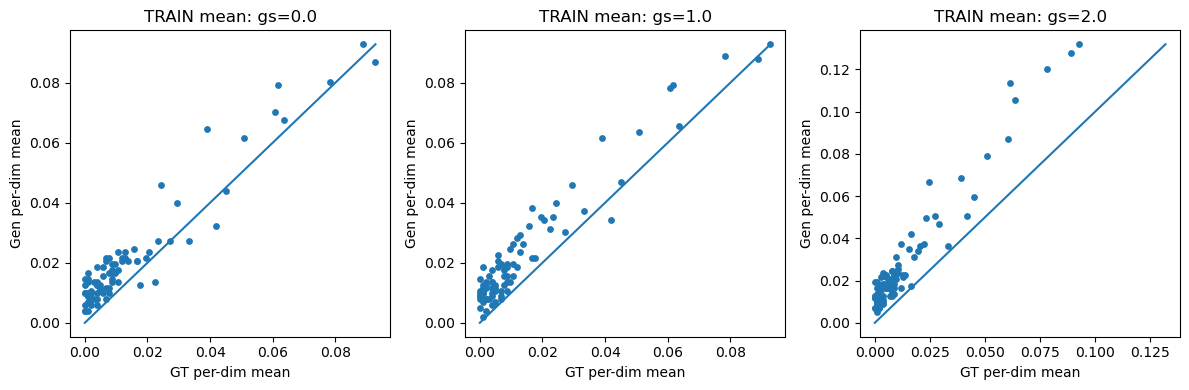

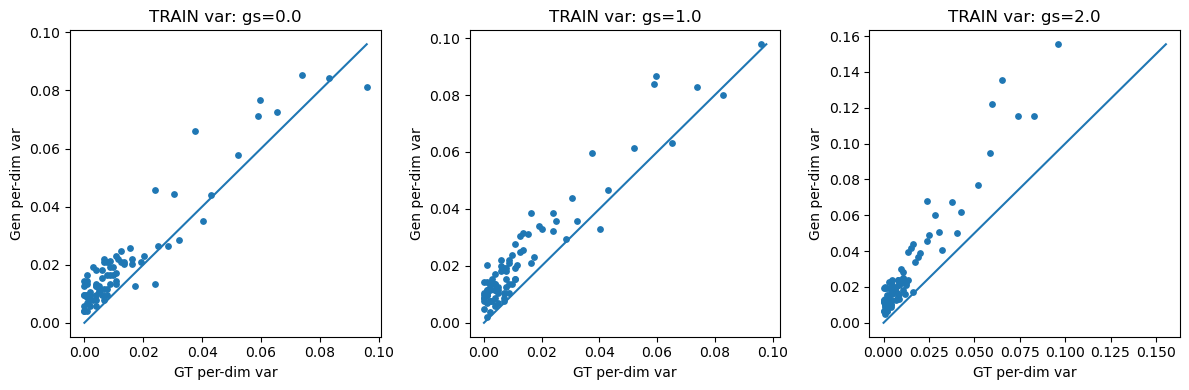

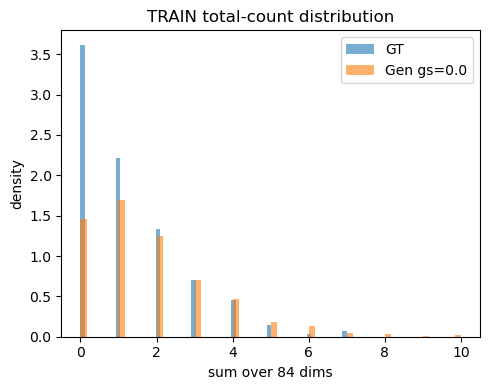

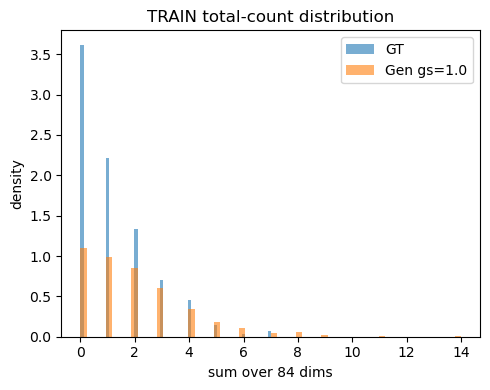

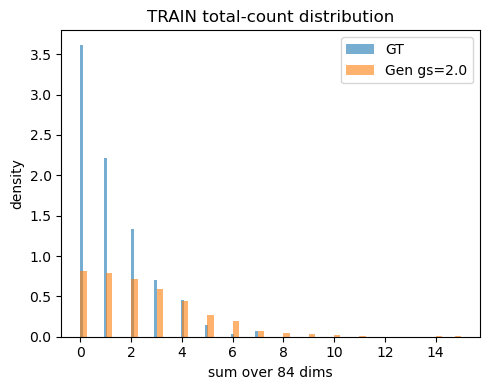

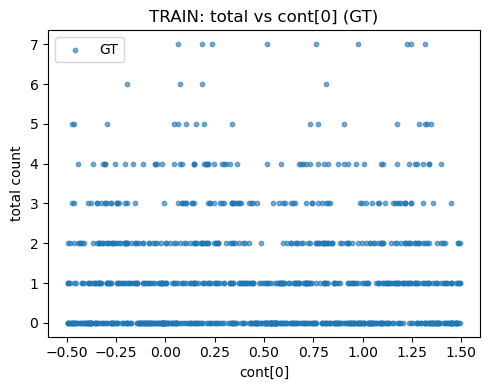

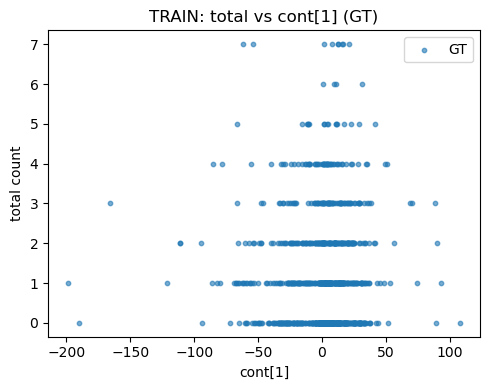

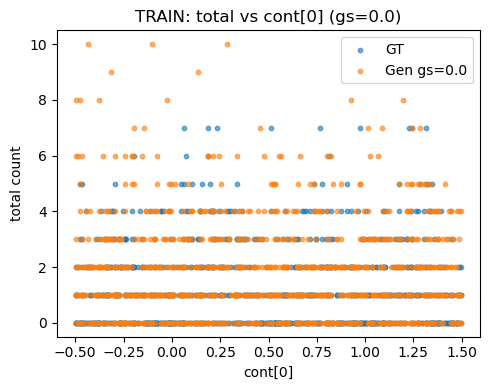

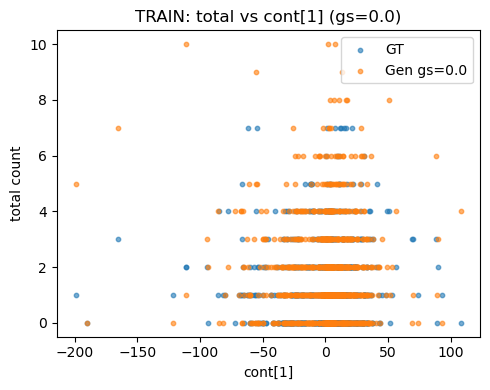

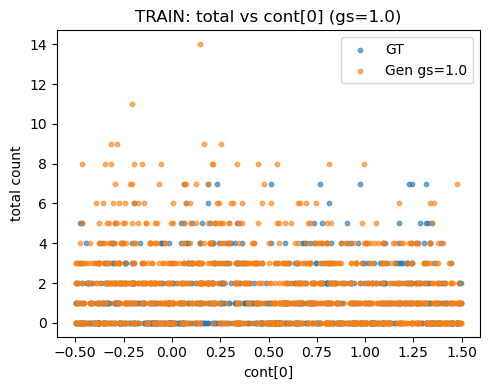

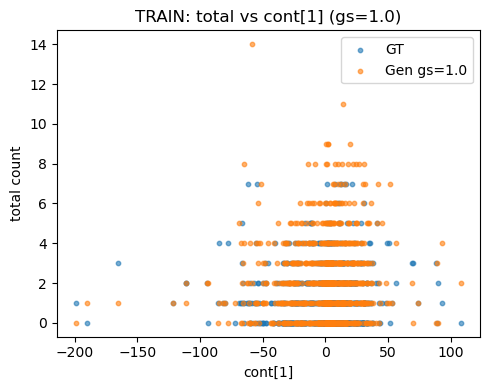

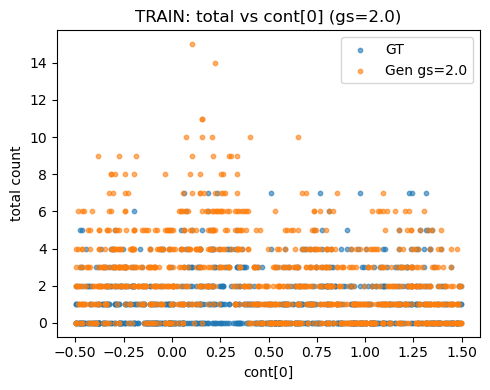

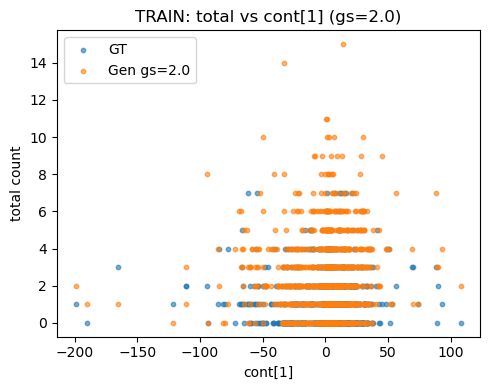

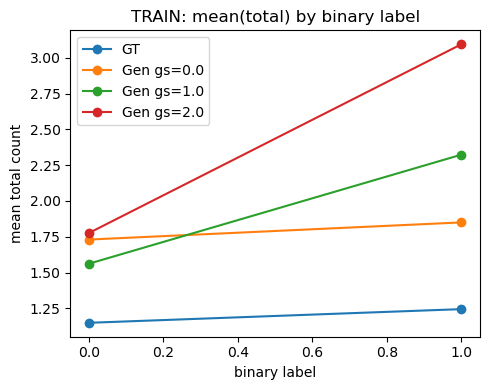

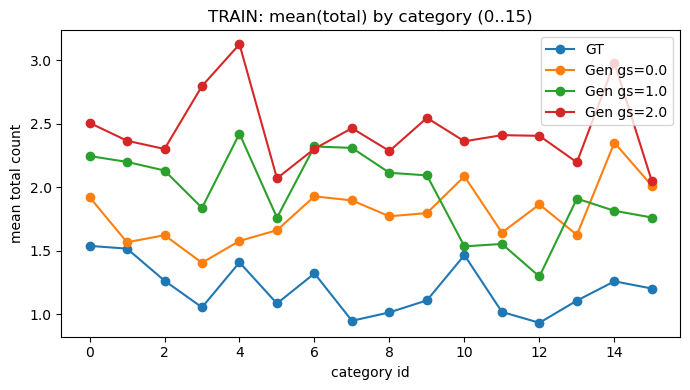


===== VAL/TEST metrics =====
GT corr(total, cont0): -0.008002096281308707
GT corr(total, cont1): -0.04907370948770635

-- gs=0.0 --
mean MAE (per-dim): 0.008056640625
var  MAE (per-dim): 0.008373085143310683
total mean diff: 0.5517578125
total std  diff: 0.17414701977004632
Gen corr(total, cont0): -0.033950284193308616
Gen corr(total, cont1): 0.051076164044299835

-- gs=1.0 --
mean MAE (per-dim): 0.007614862351190476
var  MAE (per-dim): 0.007902390545322782
total mean diff: 0.5595703125
total std  diff: 0.29893685074959153
Gen corr(total, cont0): -0.1694403118853984
Gen corr(total, cont1): 0.07079545202547458

-- gs=2.0 --
mean MAE (per-dim): 0.013020833333333334
var  MAE (per-dim): 0.014502042106219701
total mean diff: 1.091796875
total std  diff: 0.6810027024183292
Gen corr(total, cont0): -0.3008751532985828
Gen corr(total, cont1): 0.06839252207556137


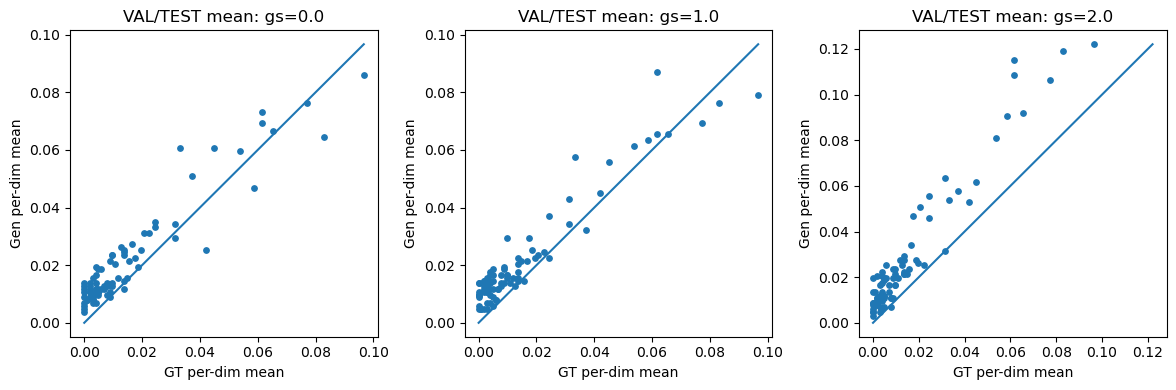

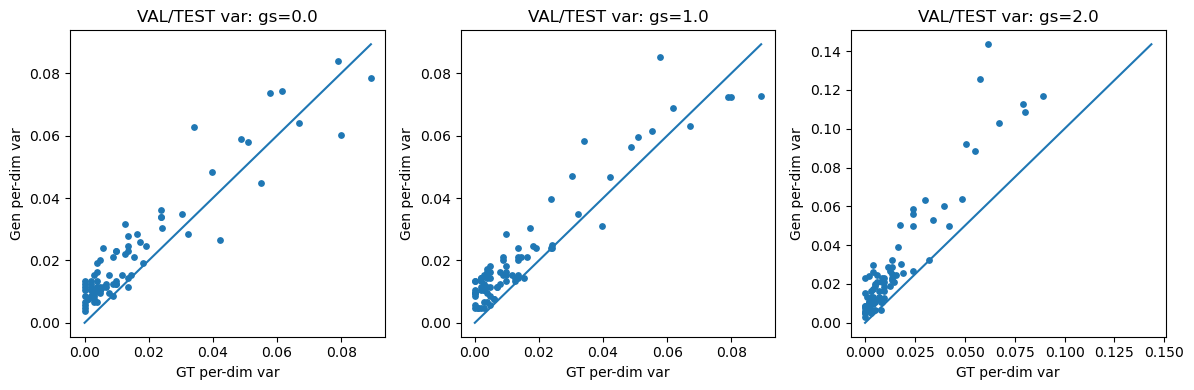

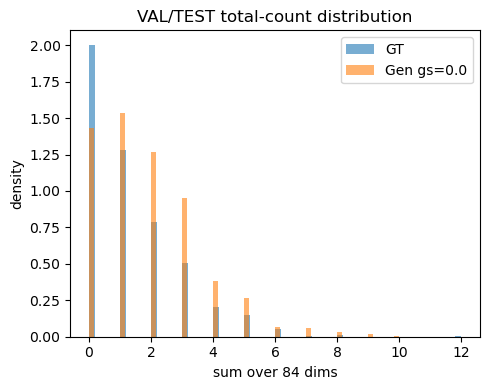

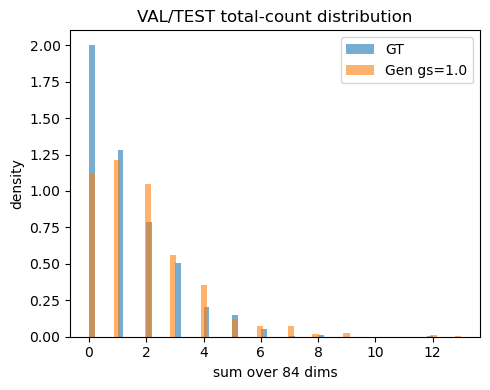

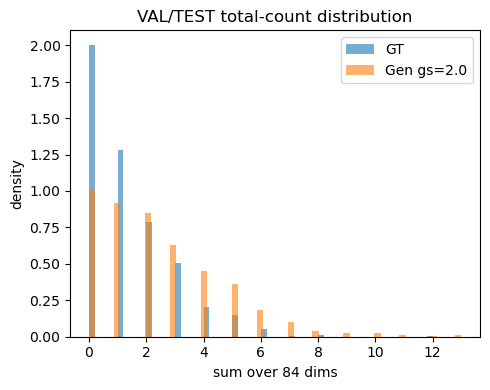

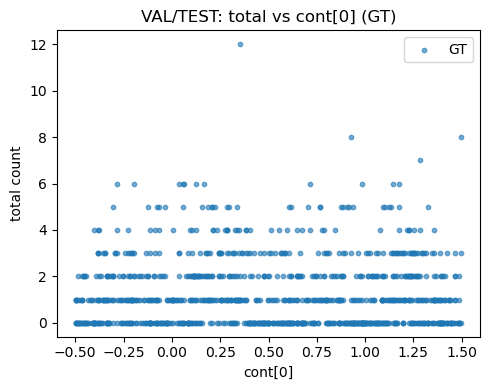

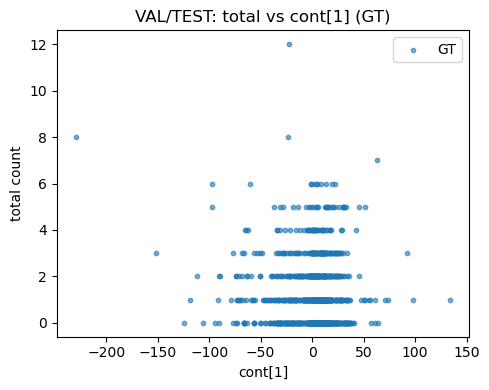

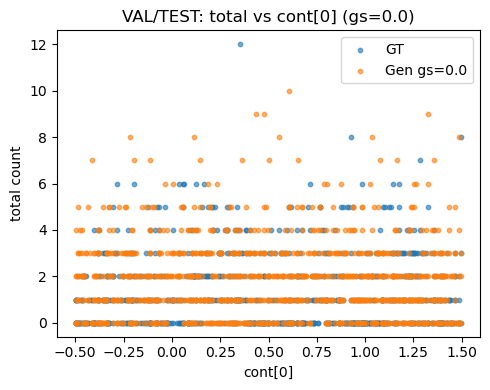

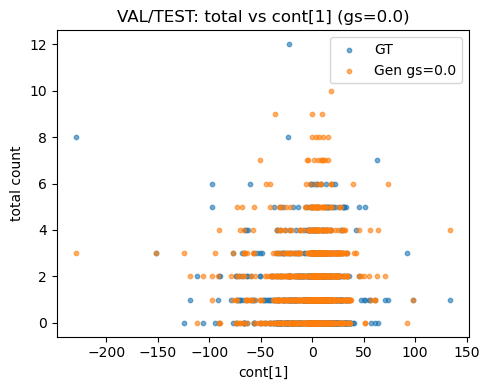

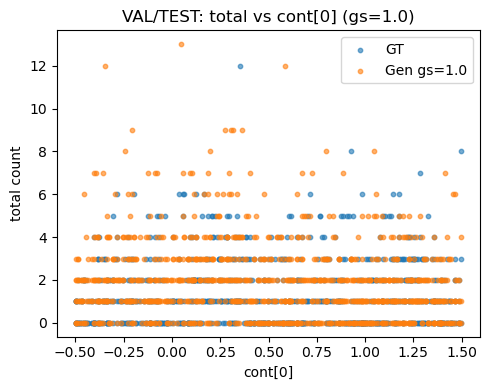

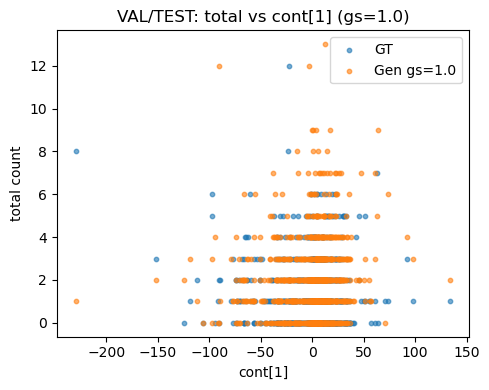

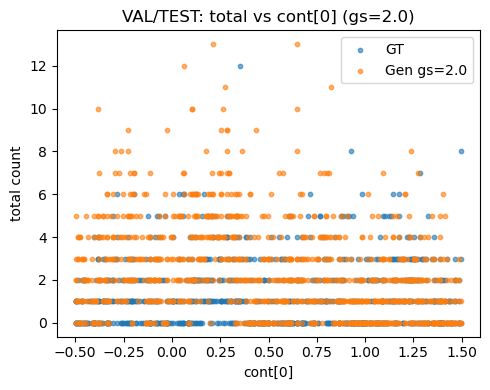

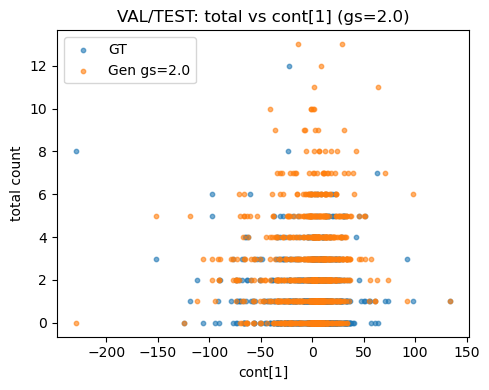

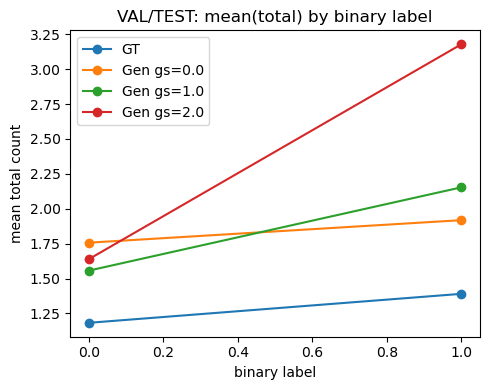

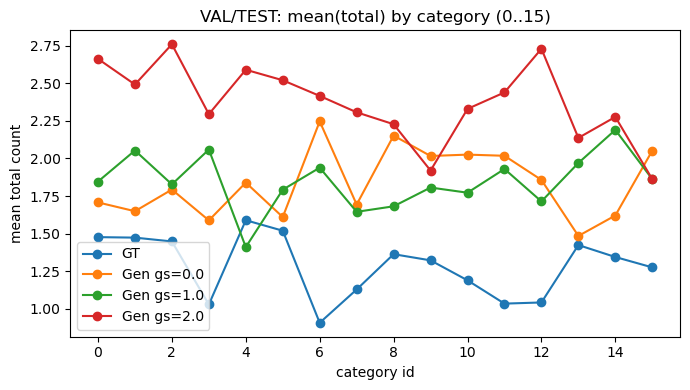

In [46]:
guidance_scales = [0.0, 1.0, 2.0]   # 0.0 = unconditional, 1.0 = standard, 2.0 = stronger
n_eval = 1024                      # how many samples to check
n_step_eval = 400                  # Euler step (400 should be enough)

net = net.to(device)

def run_split(split_name, ds, seed=0):
    X_true, ccont, cbin, ccat = _get_subset_from_ds(ds, n=n_eval, seed=seed)
    x0 = torch.randint(
        0, C_max + 1,
        size=X_true.shape,
        device=torch.device("cpu"),
        dtype=torch.long
    ).float()

    gen_dict = {}
    for gs in guidance_scales:
        Xg = _gen_from_covariates(net, x0, ccont, cbin, ccat, guidance_scale=gs, n_step=n_step_eval)
        gen_dict[gs] = Xg

    _print_metrics(split_name, X_true, ccont, cbin, ccat, gen_dict)
    _plot_marginal_fit(split_name, X_true, gen_dict)
    _plot_conditional_fit(split_name, X_true, ccont, cbin, ccat, gen_dict)

# run on train and val
run_split("TRAIN", train_ds, seed=0)
run_split("VAL/TEST", val_ds, seed=1)

In [47]:
save_path = "cond_countfm_cfg_ckpt.pt"

ckpt = {
    "state_dict": net.state_dict(),
    "C_max": int(C_max),
    "model_kwargs": dict(
        d=int(d),
        cont_dim=2,
        bin_classes=2,
        cat_classes=16,
        emb_dim=16,
        hidden=256,
        depth=3,
        eps_out=1e-6,
    ),
}

torch.save(ckpt, save_path)
print("saved to:", save_path)

saved to: cond_countfm_cfg_ckpt.pt


In [48]:
# ckpt = torch.load("cond_countfm_cfg_ckpt.pt", map_location="cpu")
# net2 = CondCountFMNet(**ckpt["model_kwargs"])
# net2.load_state_dict(ckpt["state_dict"])
# C_max2 = ckpt["C_max"]

# net2 = net2.to(device).eval()
# print("loaded. C_max2 =", C_max2)


[TRAIN] GT overall zero frac = 0.9859
  gs=0.0: Gen overall zero frac = 0.9782 | per-dim zero MAE = 0.0077


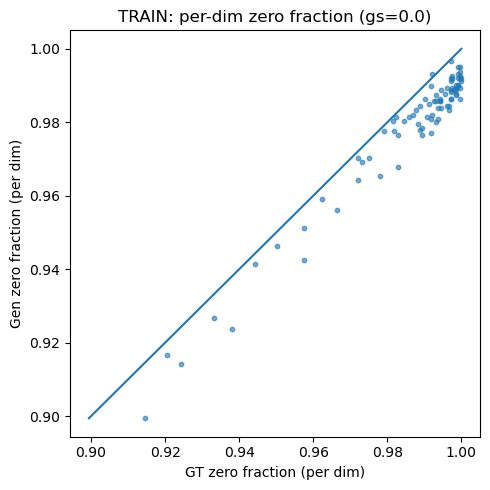

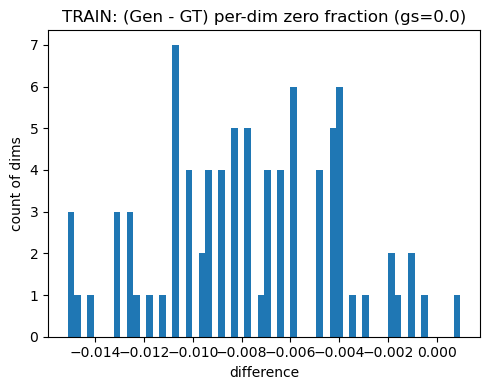

  gs=1.0: Gen overall zero frac = 0.9786 | per-dim zero MAE = 0.0074


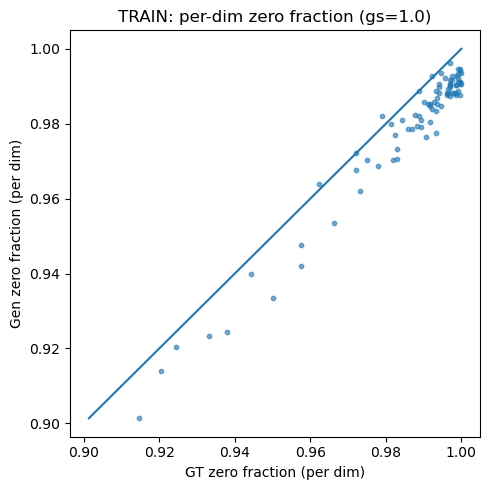

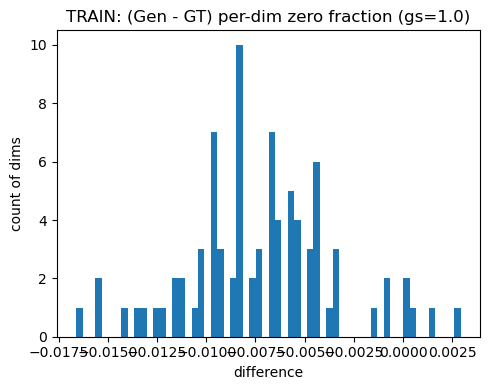

  gs=2.0: Gen overall zero frac = 0.9737 | per-dim zero MAE = 0.0123


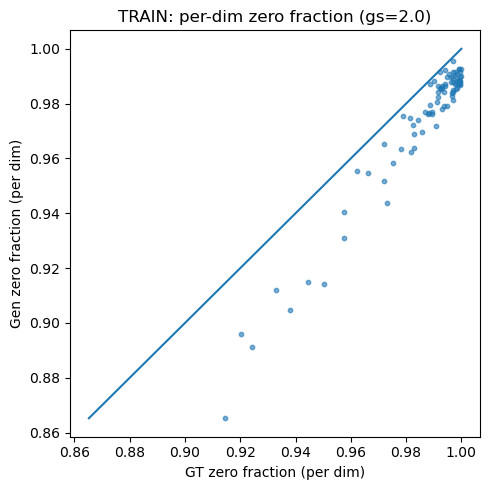

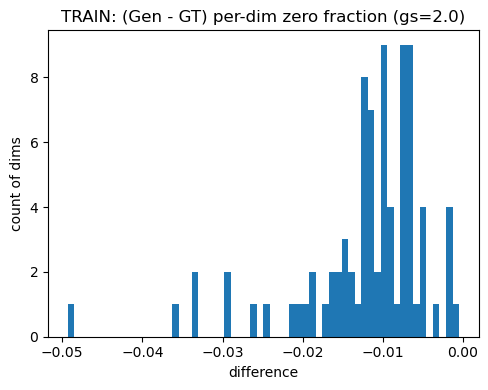


[VAL/TEST] GT overall zero frac = 0.9853
  gs=0.0: Gen overall zero frac = 0.9781 | per-dim zero MAE = 0.0078


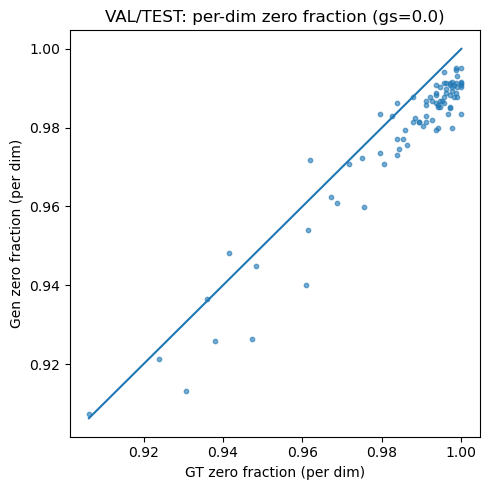

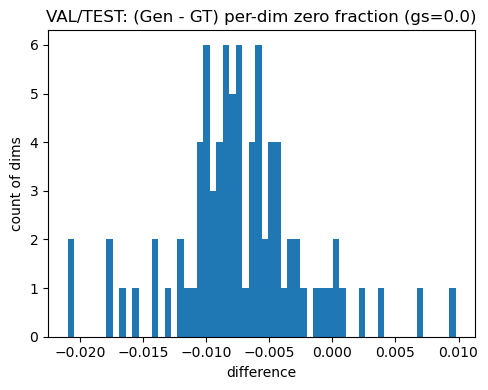

  gs=1.0: Gen overall zero frac = 0.9790 | per-dim zero MAE = 0.0071


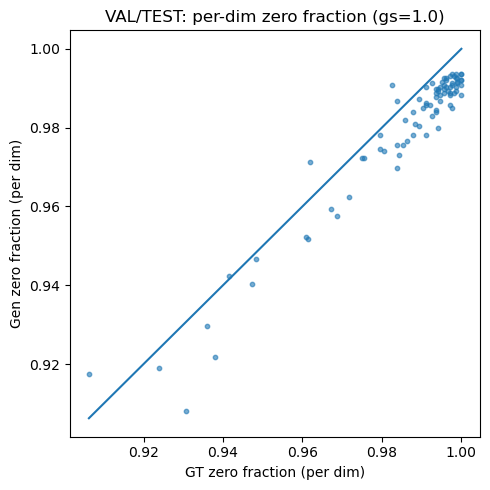

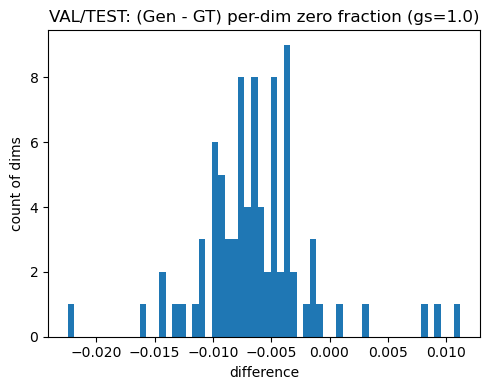

  gs=2.0: Gen overall zero frac = 0.9731 | per-dim zero MAE = 0.0123


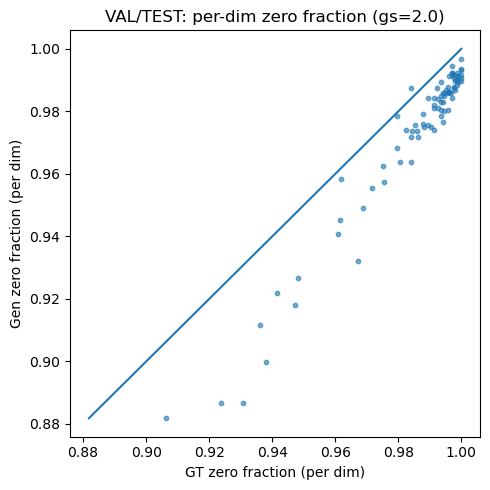

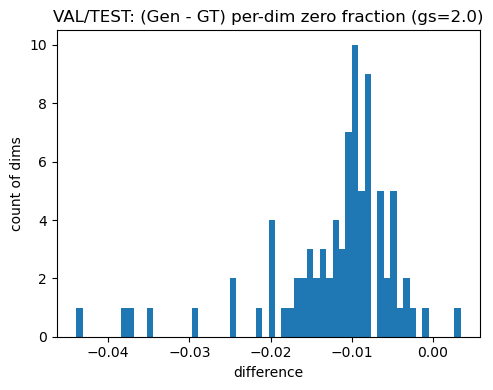

In [49]:
def zero_stats(X):
    # X: torch [N,d]
    X = X.float()
    per_dim = (X == 0).float().mean(0).cpu().numpy()          # [d]
    overall = float((X == 0).float().mean().cpu().item())     # scalar
    return per_dim, overall

def check_zero_fit(split_name, ds, guidance_scales=(0.0, 1.0, 2.0), n_eval=2048, n_step=400, seed=0):
    X_true, ccont, cbin, ccat = _get_subset_from_ds(ds, n=n_eval, seed=seed)

    # same x0 for all gs so differences come only from guidance
    x0 = torch.randint(0, C_max + 1, size=X_true.shape, device=torch.device("cpu"), dtype=torch.long).float()

    z_true_dim, z_true_all = zero_stats(X_true)
    print(f"\n[{split_name}] GT overall zero frac = {z_true_all:.4f}")

    for gs in guidance_scales:
        Xg = _gen_from_covariates(net, x0, ccont, cbin, ccat, guidance_scale=gs, n_step=n_step)
        z_gen_dim, z_gen_all = zero_stats(Xg)

        mae_dim = float(np.mean(np.abs(z_gen_dim - z_true_dim)))
        print(f"  gs={gs}: Gen overall zero frac = {z_gen_all:.4f} | per-dim zero MAE = {mae_dim:.4f}")

        # per-dim scatter
        plt.figure(figsize=(5,5))
        plt.scatter(z_true_dim, z_gen_dim, s=10, alpha=0.6)
        mn = min(z_true_dim.min(), z_gen_dim.min())
        mx = max(z_true_dim.max(), z_gen_dim.max())
        plt.plot([mn, mx], [mn, mx])
        plt.title(f"{split_name}: per-dim zero fraction (gs={gs})")
        plt.xlabel("GT zero fraction (per dim)")
        plt.ylabel("Gen zero fraction (per dim)")
        plt.tight_layout()
        plt.show()

        # histogram of per-dim differences
        plt.figure(figsize=(5,4))
        plt.hist(z_gen_dim - z_true_dim, bins=60)
        plt.title(f"{split_name}: (Gen - GT) per-dim zero fraction (gs={gs})")
        plt.xlabel("difference")
        plt.ylabel("count of dims")
        plt.tight_layout()
        plt.show()

check_zero_fit("TRAIN", train_ds, guidance_scales=(0.0, 1.0, 2.0), n_eval=2048, n_step=400, seed=0)
check_zero_fit("VAL/TEST", val_ds, guidance_scales=(0.0, 1.0, 2.0), n_eval=2048, n_step=400, seed=1)